# Marta Negri
# Luca Davì

## Taks 2:
assessing the performance of pre-trained models in a zero-shot setting, where no additional training on waste images is performed. This will provide insights
into the generalization capabilities of modern detectors such as YOLO, DETR, and RT-DETR.
After the initial evaluation, fine-tune a small variant of the RT-DETR model on the training split
of the waste images dataset, and assess and discuss its performance, comparing it to the other
models

notes for mac users: We had to switch to colab because of an unimplemented function in the trainer that forced the fall back to cpu, this meant that each training epoch would take 5 minutes, making training impossible

In [1]:
# this works only if you are running in google colab and have the data stored in your google drive
# from google.colab import drive
# import sys
# drive.mount('/content/drive')

# !unzip -oq /content/drive/MyDrive/data.zip -d /content/taco_subset
# sys.path.append('/content/drive/MyDrive/')



In [1]:
!pip install -q gdown
#https://drive.google.com/file/d/1e4tsIf_jCotS91V-5BDJH-gEPphQDydz/view?usp=share_link
#https://drive.google.com/file/d/1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv/view?usp=share_link
FILE_ID = "1e4tsIf_jCotS91V-5BDJH-gEPphQDydz" #dataset
!gdown --id $FILE_ID -O /content/data.zip
FILE_ID = "1DbZpXp-j8hy4EwN6ZgIvBz4z2v-MANhv" #library
!gdown --id $FILE_ID -O /content/taco_dataset.py

!unzip -oq /content/data.zip -d /content/taco_subset



C:\Users\utente\anaconda3\envs\cv_labs\lib\site-packages\gdown\__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Error:

	[WinError 3] Impossibile trovare il percorso specificato: '/content'

To report issues, please visit https://github.com/wkentaro/gdown/issues.
C:\Users\utente\anaconda3\envs\cv_labs\lib\site-packages\gdown\__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Error:

	[WinError 3] Impossibile trovare il percorso specificato: '/content'

To report issues, please visit https://github.com/wkentaro/gdown/issues.
"unzip" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


### 2.1 Dataset Preparation

In [2]:
%pip install pycocotools ultralytics torchmetrics

Note: you may need to restart the kernel to use updated packages.


In [43]:
import os

os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torchvision
import torch
import matplotlib.pyplot as plt
import numpy as np


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
###############################################################################
# I CHANGED THIS BECAUSE IT WASN'T WORKING FOR ME
################################################################################

root = './data/TACO_subset'
train_ann='./data/TACO_subset/annotations_train.json'

train_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_train.json', transform=None)
test_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_test.json', transform=None)
val_dataset = torchvision.datasets.CocoDetection(root=root, annFile=root+'/annotations_val.json', transform=None)
#yolo and detr require images in different formats with different pipelines

train_dataset[0]

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


(<PIL.Image.Image image mode=RGB size=768x1024>,
 [{'id': 1,
   'image_id': 0,
   'category_id': 2,
   'segmentation': [[280.3175016265452,
     618.6979014153246,
     283.8152244632401,
     600.2069302098585,
     283.31554977228365,
     587.2132747681796,
     274.32140533506833,
     563.2249877989263,
     268.8249837345478,
     544.2342606149341,
     259.33116460637603,
     521.2454856027331,
     258.33181522446324,
     502.25475841874083,
     261.3298633702017,
     481.76476329917034,
     264.3279115159402,
     472.2693997071742,
     259.8308392973325,
     447.78135675939484,
     262.32921275211453,
     430.7896534895071,
     267.825634352635,
     410.29965836993654,
     276.8197787898504,
     384.3123474865788,
     288.3122966818478,
     363.3225963884822,
     297.3064411190631,
     338.8345534407028,
     297.80611581001955,
     292.3572474377745,
     293.80871828236826,
     172.91556857003417,
     290.31099544567337,
     163.91996095656418,
     28

In [4]:
train_length = len(train_dataset)
test_length = len(test_dataset)
val_length = len(val_dataset)
tot_length = train_length + test_length + val_length

print(f"Train dataset length: {train_length}: {train_length/tot_length*100:.2f}% of total")
print(f"Test dataset length: {test_length}: {test_length/tot_length*100:.2f}% of total")
print(f"Validation dataset length: {val_length}: {val_length/tot_length*100:.2f}% of total")

Train dataset length: 799: 69.66% of total
Test dataset length: 178: 15.52% of total
Validation dataset length: 170: 14.82% of total


In [42]:
# Class statistics per split (using COCO JSON files) 
from pycocotools.coco import COCO
from collections import Counter
import pandas as pd

def coco_class_stats_from_file(ann_file, split_name):
    """
    Compute number of instances per category
    Returns a DataFrame with columns:
    [split, category_id, category_name, num_instances]
    """
    coco = COCO(ann_file)

    # All category IDs and names
    cat_ids = coco.getCatIds()
    cat_id_to_name = {c['id']: c['name'] for c in coco.loadCats(cat_ids)}

    # All annotations in this split
    ann_ids = coco.getAnnIds()
    anns = coco.loadAnns(ann_ids)

    # Count category occurrences
    counter = Counter([ann['category_id'] for ann in anns])

    rows = []
    for cid in cat_ids:
        rows.append({
            "split": split_name,
            "category_id": cid,
            "category_name": cat_id_to_name[cid],
            "num_instances": counter.get(cid, 0),
        })

    return pd.DataFrame(rows)

# Use existing annotation paths
train_ann_file = root + "/annotations_train.json"
val_ann_file   = root + "/annotations_val.json"
test_ann_file  = root + "/annotations_test.json"

# Compute stats for each split
train_stats = coco_class_stats_from_file(train_ann_file, "train")
val_stats   = coco_class_stats_from_file(val_ann_file, "val")
test_stats  = coco_class_stats_from_file(test_ann_file, "test")

# Combine all into a single table
all_stats = pd.concat([train_stats, val_stats, test_stats], ignore_index=True)

print("Per-class instance counts per split:")
display(all_stats.sort_values(["category_name", "split"]).reset_index(drop=True))
 #aggregate total instances per class across all splits
total_per_class = (
    all_stats
    .groupby(["category_id", "category_name"])["num_instances"]
    .sum()
    .reset_index()
    .sort_values("num_instances", ascending=False)
)

print("Total instances per class (all splits combined):")
display(total_per_class)

# save to CSV
all_stats.to_csv("taco_class_stats_per_split.csv", index=False)
total_per_class.to_csv("taco_class_stats_total.csv", index=False)


loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Per-class instance counts per split:


,split,category_id,category_name,num_instances
0,test,2,Bottle,54
1,test,2,Bottle,54
2,test,2,Bottle,54
3,train,2,Bottle,314
4,train,2,Bottle,314
...,...,...,...,...
175,val,-1,Unlabeled litter,0
176,val,-1,Unlabeled litter,0
177,val,-1,Unlabeled litter,0
178,val,-1,Unlabeled litter,0


Total instances per class (all splits combined):


,category_id,category_name,num_instances
1,0,Plastic bag & wrapper,5950
6,5,Carton,1757
3,2,Bottle,1317
5,4,Can,819
2,1,Cigarette,667
4,3,Bottle cap,578
0,-1,Unlabeled litter,0


In [1]:
# Visualize three samples from each split with the corresponding category labels with category names

indexes = torch.randint(0, min(train_length, test_length, val_length), (3,)).tolist()

fig, axs = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    axs[0, i].imshow(train_dataset[indexes[i]][0])
    axs[0, i].set_title(f"Train Sample {i+1}\nCategory: {train_dataset[indexes[i]][1][0]['category_id']}\nName: {train_dataset.coco.loadCats(train_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[0, i].axis('off')

    axs[1, i].imshow(test_dataset[indexes[i]][0])
    axs[1, i].set_title(f"Test Sample {i+1}\nCategory: {test_dataset[indexes[i]][1][0]['category_id']}\nName: {test_dataset.coco.loadCats(test_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[1, i].axis('off')

    axs[2, i].imshow(val_dataset[indexes[i]][0])
    axs[2, i].set_title(f"Validation Sample {i+1}\nCategory: {val_dataset[indexes[i]][1][0]['category_id']}\nName: {val_dataset.coco.loadCats(val_dataset[indexes[i]][1][0]['category_id'])[0]['name']}")
    axs[2, i].axis('off')

NameError: name 'torch' is not defined

The bar chart visualizes the class distribution, highlighting which waste categories are more or less frequent

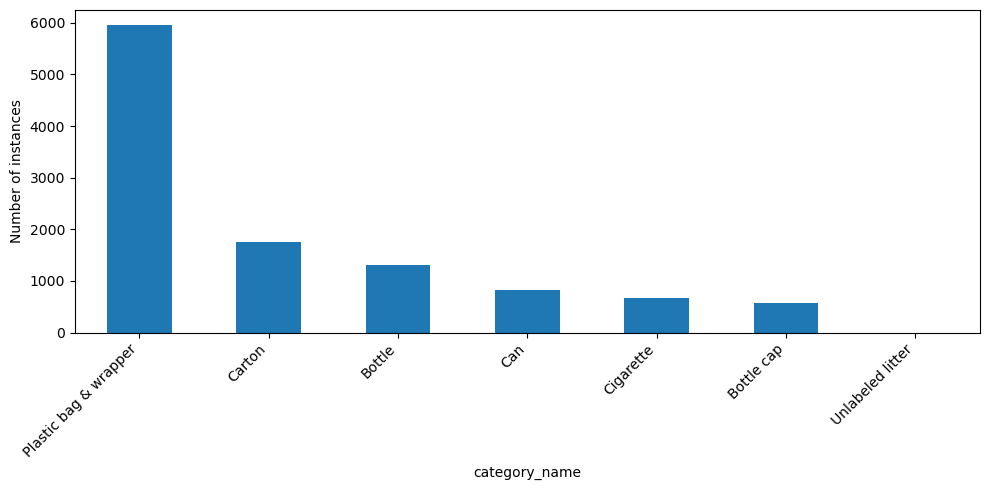

In [44]:
total_per_class.plot(
    x="category_name",
    y="num_instances",
    kind="bar",
    figsize=(10,5),
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of instances")
plt.tight_layout()
plt.show()


## subtask 2.2. zero-shot detection

In [5]:
#define dataloaders for each split
def collate_fn(batch): #standard collate function for object detection tasks provided in pytorch documentation
    return tuple(zip(*batch))
BATCH_SIZE = 4
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [6]:
#load models

from ultralytics import YOLO
from transformers import pipeline

yolo_model = YOLO('yolo11m.pt').to(device)
detr_model = pipeline('object-detection', model='facebook/detr-resnet-50',device=device)
rt_detr_model = pipeline('object-detection', model='PekingU/rtdetr_r50vd',device=device)

print(f'Models are on device: \nYOLO: {yolo_model.device}\nDETR device: {detr_model.device}\nRT-DETR device: {rt_detr_model.device}')


c:\Users\utente\anaconda3\envs\cv_labs\lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\utente\anaconda3\envs\cv_labs\lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
c:\Users\utente\anaconda3\envs\cv_labs\lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the cu

Models are on device: 
YOLO: cuda:0
DETR device: cuda
RT-DETR device: cuda


In [8]:
def dataset_to_torchmetrics(target):
    #convert coco annotations to torchmetrics format
    boxes = []
    labels = []
    for ann in target:
        box = ann['bbox']
        #coco format is [x_min, y_min, width, height], convert to [x_min, y_min, x_max, y_max]
        box = [box[0], box[1], box[0] + box[2], box[1] + box[3]]
        boxes.append(box)
        labels.append(0) #we don't consider classes, set all to 0
    return {'boxes': torch.tensor(boxes, dtype=torch.float32), 'labels': torch.tensor(labels, dtype=torch.int64)}

def yolo_to_torchmetrics(yolo_results, original_size, IMG_SIZE=640):
    yolo_boxes = yolo_results.boxes.xyxy
    # Rescale boxes to original image size
    yolo_boxes[:, [0, 2]] *= original_size[0] / IMG_SIZE
    yolo_boxes[:, [1, 3]] *= original_size[1] / IMG_SIZE
    return {
        "boxes": yolo_boxes,
        "scores": yolo_results.boxes.conf,
        "labels": torch.zeros(len(yolo_results.boxes.xyxy), dtype=torch.int64), # Ignoring class
    }

def detr_to_torchmetrics(detr_results, confidence_threshold=0.1):
    detr_results = [res for res in detr_results if res['score'] >= confidence_threshold]
    if len(detr_results) == 0:
        return {
            "boxes": torch.empty((0, 4), dtype=torch.float32),
            "scores": torch.empty((0,), dtype=torch.float32),
            "labels": torch.empty((0,), dtype=torch.int64), # Ignoring class
        }
    boxes = []
    scores = []
    for res in detr_results:
        box = res['box']
        if isinstance(box, dict):
            boxes.append([box['xmin'], box['ymin'], box['xmax'], box['ymax']])
        else:
            x,y,w,h = box
            boxes.append([x, y, x + w, y + h])
        scores.append(res['score'])
    return {
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "scores": torch.tensor(scores, dtype=torch.float32),
        "labels": torch.zeros(len(boxes), dtype=torch.int64), # Ignoring class
    }

In [9]:
def yolo_top_IoU(yolo_pred, target, n_boxes=10):
    # receive boxes predictions and target boxes for single image
    # select top-10 predictions based on confidence
    # for each target box compute IoU with 10 predictions
    # select prediction with highest IoU [delete from set]
    # final set of predictions is given to mAP
    top_indexes = torch.argsort(yolo_pred["scores"], descending=True)[:n_boxes]
    selected_boxes = yolo_pred["boxes"][top_indexes]
    selected_scores = yolo_pred["scores"][top_indexes]

    #ensure same device
        # selected_boxes = selected_boxes.to(device)
        # selected_scores = selected_scores.to(device)
        # target_boxes = target['boxes'].to(device)

    ious = torchvision.ops.box_iou(selected_boxes, target["boxes"])  # shape: (n_selected, n_target)
    matched_indexes = set()
    final_boxes = []
    final_scores = []

    for target_idx in range(ious.size(1)):
        available_indexes = [i for i in range(ious.size(0)) if i not in matched_indexes]
        if not available_indexes:
            break
        target_ious = ious[available_indexes, target_idx]
        best_iou_idx = available_indexes[torch.argmax(target_ious).item()]
        matched_indexes.add(best_iou_idx)
        final_boxes.append(selected_boxes[best_iou_idx].unsqueeze(0))
        final_scores.append(selected_scores[best_iou_idx].unsqueeze(0))

    return {
        "boxes": torch.cat(final_boxes, dim=0) if final_boxes else torch.empty((0,4), dtype=torch.float32),
        "scores": torch.cat(final_scores, dim=0) if final_scores else torch.empty((0,), dtype=torch.float32),
        "labels": torch.zeros(len(final_boxes), dtype=torch.int64), # Ignoring class
    }

def detr_top_IoU(detr_pred, target, n_boxes=10):
    # receive boxes predictions and target boxes for single image
    # select top-10 predictions based on confidence
    # for each target box compute IoU with 10 predictions
    # select prediction with highest IoU [delete from set]
    # final set of predictions is given to mAP

    top_indexes = torch.argsort(detr_pred['scores'], descending=True)[:n_boxes]
    selected_boxes = detr_pred['boxes'][top_indexes]
    selected_scores = detr_pred['scores'][top_indexes]

    ious = torchvision.ops.box_iou(selected_boxes, target['boxes'])  # shape: (n_selected, n_target)
    matched_indexes = set()
    final_boxes = []
    final_scores = []

    for target_idx in range(ious.size(1)):
        available_indexes = [i for i in range(ious.size(0)) if i not in matched_indexes]
        if not available_indexes:
            break
        target_ious = ious[available_indexes, target_idx]
        best_iou_idx = available_indexes[torch.argmax(target_ious).item()]
        matched_indexes.add(best_iou_idx)
        final_boxes.append(selected_boxes[best_iou_idx].unsqueeze(0))
        final_scores.append(selected_scores[best_iou_idx].unsqueeze(0))

    return {
        "boxes": torch.cat(final_boxes, dim=0) if final_boxes else torch.empty((0,4), dtype=torch.float32),
        "scores": torch.cat(final_scores, dim=0) if final_scores else torch.empty((0,), dtype=torch.float32),
        "labels": torch.zeros(len(final_boxes), dtype=torch.int64), # Ignoring class
    }

In [46]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
IMG_SIZE = 640
def evaluate_models(yolo_model, detr_model, rt_detr_model, data_loader,
                    yolo_conf=0.25, detr_conf=0.1, rt_detr_conf=0.1):


    metric_yolo = MeanAveragePrecision(class_metrics=False)
    metric_detr = MeanAveragePrecision(class_metrics=False)
    metric_rt_detr = MeanAveragePrecision(class_metrics=False)

    iou_metric_yolo = MeanAveragePrecision(class_metrics=False)
    iou_metric_detr = MeanAveragePrecision(class_metrics=False)
    iou_metric_rt_detr = MeanAveragePrecision(class_metrics=False)
    # yolo_confs = []
    # detr_scores = []
    # rt_detr_scores = []
    with torch.no_grad():
        for images, targets in data_loader:
            original_sizes = [img.size for img in images]  # Store original sizes for image rescaling
            yolo_batch = torch.stack(
                [torchvision.transforms.ToTensor()(
                    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE))(img))
                    for img in images]) #YOLO is happier with tensor [B,C,W,H], but doesn't handle resizing internally

            #YOLO inference
            yolo_results = yolo_model(yolo_batch, conf=yolo_conf, verbose=False)

            #DETR inference
            detr_batch = [img.convert("RGB") if img.mode != "RGB" else img for img in images] #DETR needs PIL RGB images
            detr_results = detr_model(detr_batch)
            #RT-DETR inference
            rt_detr_results = rt_detr_model(detr_batch)

            #transform target to map format
            targets = [dataset_to_torchmetrics(t) for t in targets]
            #yolo_results are the only one on device instead of cpu, move them
            yolo_results = [res.to('cpu') for res in yolo_results]
            #targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            #determine top k predictions for each model, where k is the number of ground truth boxes in the image
            for og_size,target,yolo_res,detr_res,rt_detr_res in zip(original_sizes,targets,yolo_results,detr_results,rt_detr_results):
                k = target["boxes"].shape[0]
                yolo_sorted_indices = torch.argsort(yolo_res.boxes.conf, descending=True)[:k]
                yolo_topk = yolo_res[yolo_sorted_indices]

                detr_topk = sorted(detr_res, key=lambda x: x['score'], reverse=True)[:k]
                rt_detr_topk = sorted(rt_detr_res, key=lambda x: x['score'], reverse=True)[:k]

                metric_yolo.update([yolo_to_torchmetrics(yolo_topk, og_size, IMG_SIZE)], [target])
                metric_detr.update([detr_to_torchmetrics(detr_topk, confidence_threshold=detr_conf)],[target])
                metric_rt_detr.update([detr_to_torchmetrics(rt_detr_topk, confidence_threshold=rt_detr_conf)],[target])


                # print(target['boxes'].device)
                # print(yolo_res.boxes.xyxy.device)
                # print(detr_to_torchmetrics(detr_res)['boxes'].device)

                iou_metric_yolo.update([yolo_top_IoU(yolo_to_torchmetrics(yolo_res, og_size, IMG_SIZE), target, n_boxes=10)], [target])
                iou_metric_detr.update([detr_top_IoU(detr_to_torchmetrics(detr_res, confidence_threshold=detr_conf), target, n_boxes=10)],[target])
                iou_metric_rt_detr.update([detr_top_IoU(detr_to_torchmetrics(rt_detr_res, confidence_threshold=rt_detr_conf), target, n_boxes=10)],[target])

    return metric_yolo.compute(), metric_detr.compute(), metric_rt_detr.compute(), iou_metric_yolo.compute(), iou_metric_detr.compute(), iou_metric_rt_detr.compute()


### We will now test each of the model for different tresholds [0.10, 0.25, 0.50, 0.75, 0.90]

In [51]:
def extract_scalar_metrics(metric_dict):
    keys = [
        "map", "map_50", "map_75",
        "map_small", "map_medium", "map_large",
        "mar_1", "mar_10", "mar_100",
        "mar_small", "mar_medium", "mar_large",
    ]
    out = {}
    for k in keys:
        if k in metric_dict:
            v = metric_dict[k]
            out[k] = v.item() if hasattr(v, "item") else float(v)
    return out


conf_thresholds = [0.10, 0.25, 0.50, 0.75, 0.90]

results_zero_shot = []

for conf in conf_thresholds:
    print(f"\n=== Evaluating zero-shot on TACO – conf = {conf} ===")
    
    yolo_map, detr_map, rt_detr_map, iou_yolo_map, iou_detr_map, iou_rt_detr_map = evaluate_models(
        yolo_model,
        detr_model,
        rt_detr_model,
        test_loader,
        yolo_conf=conf,
        detr_conf=conf,
        rt_detr_conf=conf,
    )
    
    results_zero_shot.append({
        "model": "YOLO",
        "selection": "top-k",
        "conf": conf,
        **extract_scalar_metrics(yolo_map),
    })
    results_zero_shot.append({
        "model": "DETR",
        "selection": "top-k",
        "conf": conf,
        **extract_scalar_metrics(detr_map),
    })
    results_zero_shot.append({
        "model": "RT-DETR",
        "selection": "top-k",
        "conf": conf,
        **extract_scalar_metrics(rt_detr_map),
    })

    results_zero_shot.append({
        "model": "YOLO",
        "selection": "IoU-top10",
        "conf": conf,
        **extract_scalar_metrics(iou_yolo_map),
    })
    results_zero_shot.append({
        "model": "DETR",
        "selection": "IoU-top10",
        "conf": conf,
        **extract_scalar_metrics(iou_detr_map),
    })
    results_zero_shot.append({
        "model": "RT-DETR",
        "selection": "IoU-top10",
        "conf": conf,
        **extract_scalar_metrics(iou_rt_detr_map),
    })

df_zero_shot = pd.DataFrame(results_zero_shot)
display(df_zero_shot.round(3))
df_zero_shot.to_csv("task2_zero_shot_taco_results.csv", index=False)



=== Evaluating zero-shot on TACO – conf = 0.1 ===

=== Evaluating zero-shot on TACO – conf = 0.25 ===

=== Evaluating zero-shot on TACO – conf = 0.5 ===

=== Evaluating zero-shot on TACO – conf = 0.75 ===

=== Evaluating zero-shot on TACO – conf = 0.9 ===


,model,selection,conf,map,map_50,map_75,map_small,map_medium,map_large,mar_1,mar_10,mar_100,mar_small,mar_medium,mar_large
0,YOLO,top-k,0.10,0.079,0.095,0.086,0.000,0.092,0.160,0.118,0.162,0.162,0.000,0.143,0.341
1,DETR,top-k,0.10,0.053,0.078,0.055,0.000,0.088,0.100,0.103,0.126,0.126,0.002,0.141,0.236
2,RT-DETR,top-k,0.10,0.062,0.073,0.063,0.003,0.097,0.099,0.102,0.121,0.121,0.005,0.135,0.222
3,YOLO,IoU-top10,0.10,0.105,0.132,0.110,0.000,0.112,0.211,0.132,0.187,0.187,0.000,0.171,0.386
4,DETR,IoU-top10,0.10,0.070,0.100,0.074,0.000,0.105,0.133,0.119,0.145,0.145,0.002,0.158,0.274
5,RT-DETR,IoU-top10,0.10,0.073,0.086,0.075,0.003,0.109,0.121,0.110,0.129,0.129,0.005,0.148,0.234
6,YOLO,top-k,0.25,0.059,0.069,0.066,0.000,0.069,0.122,0.091,0.112,0.112,0.000,0.090,0.244
7,DETR,top-k,0.25,0.053,0.078,0.055,0.000,0.088,0.100,0.103,0.126,0.126,0.002,0.141,0.236
8,RT-DETR,top-k,0.25,0.062,0.073,0.063,0.003,0.097,0.099,0.102,0.121,0.121,0.005,0.135,0.222
9,YOLO,IoU-top10,0.25,0.070,0.083,0.075,0.000,0.073,0.140,0.095,0.117,0.117,0.000,0.096,0.251


### below are some graphs to  better show the results obtained

Available columns: ['model', 'selection', 'conf', 'map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large']


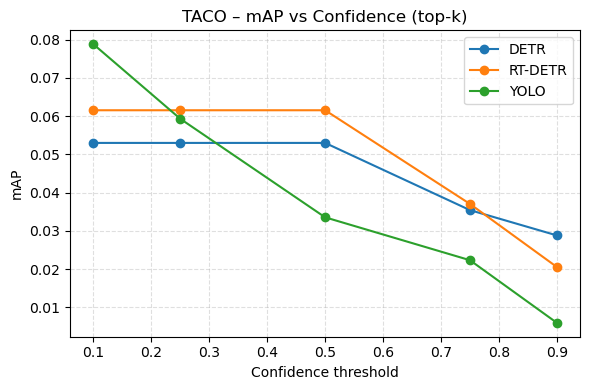

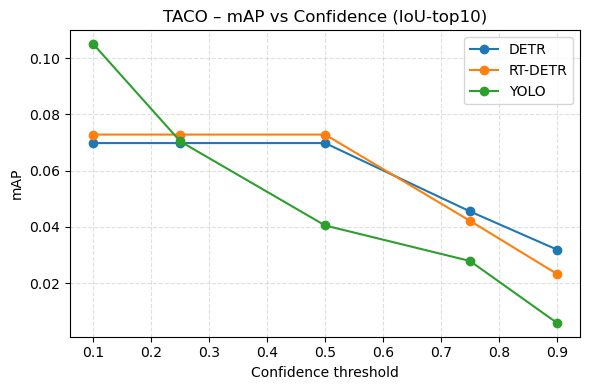

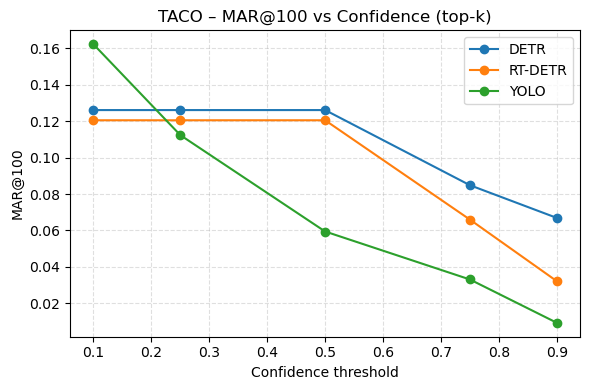

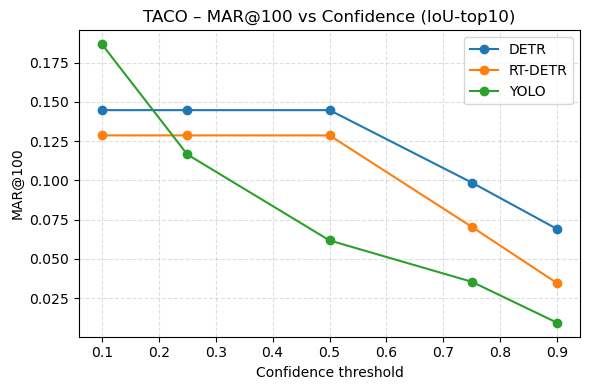

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and sort the dataset
df_zero_shot = pd.read_csv("task2_zero_shot_taco_results.csv")
df_zero_shot = df_zero_shot.sort_values(["model", "selection", "conf"]).reset_index(drop=True)

print("Available columns:", df_zero_shot.columns.tolist())

def plot_metric_vs_conf(df, metric_name, selection, title, ylabel):
    # Check whether the metric exists in the dataset
    if metric_name not in df.columns:
        print(f"[WARNING] Metric '{metric_name}' not found. "
              f"Available columns: {df.columns.tolist()}")
        return
    
    # Filter rows for the selected evaluation protocol
    subset = df[df["selection"] == selection]
    if subset.empty:
        print(f"[WARNING] No rows found for selection = '{selection}'.")
        return

    plt.figure(figsize=(6, 4))

    # Plot a curve for each model
    for model_name in subset["model"].unique():
        df_m = subset[subset["model"] == model_name]

        confs = df_m["conf"].values
        values = df_m[metric_name].values

        # Ensure points are ordered by confidence
        order = np.argsort(confs)
        confs = confs[order]
        values = values[order]

        plt.plot(confs, values, marker="o", label=model_name)

    plt.title(title)
    plt.xlabel("Confidence threshold")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------
#          VALID PLOTS
# -------------------------

# mAP (overall)
plot_metric_vs_conf(
    df_zero_shot,
    metric_name="map",
    selection="top-k",
    title="TACO – mAP vs Confidence (top-k)",
    ylabel="mAP"
)

plot_metric_vs_conf(
    df_zero_shot,
    metric_name="map",
    selection="IoU-top10",
    title="TACO – mAP vs Confidence (IoU-top10)",
    ylabel="mAP"
)

# MAR@100
plot_metric_vs_conf(
    df_zero_shot,
    metric_name="mar_100",
    selection="top-k",
    title="TACO – MAR@100 vs Confidence (top-k)",
    ylabel="MAR@100"
)

plot_metric_vs_conf(
    df_zero_shot,
    metric_name="mar_100",
    selection="IoU-top10",
    title="TACO – MAR@100 vs Confidence (IoU-top10)",
    ylabel="MAR@100"
)


The comparison in this experiment is consistent with Task 1: RT-DETR is overall the best-performing model, followed by DETR, and then YOLO.
As in Task 1, YOLO is actually the strongest only at confidence 0.10, where it briefly outperforms the transformer models. By 0.25, YOLO already drops to the same level as DETR and RT-DETR, and after that its mAP plunges much more sharply than in Task 1. This means YOLO deteriorates faster on the TACO dataset than it did on VOC.

DETR and RT-DETR instead remain relatively stable up to 0.50 and only start decreasing afterwards, with RT-DETR consistently ahead.

The difference between top-k and IoU-top10 is small and does not change the ranking of the models: the curves move slightly, but the behaviour and conclusions stay the same.

### Additional experiment: evaluating a second YOLO variant (YOLO-11s) at the baseline model’s optimal confidence to compare performance.

Best confidence for original YOLO (top-k): 0.1
YOLO size comparison at best confidence (top-k):


,model,selection,conf,map,map_50,map_75,map_small,map_medium,map_large,mar_1,mar_10,mar_100,mar_small,mar_medium,mar_large
0,YOLO-11m,top-k,0.1,0.079,0.095,0.086,0.0,0.092,0.160,0.118,0.162,0.162,0.0,0.143,0.341
1,YOLO-11s,top-k,0.1,0.070,0.086,0.073,0.0,0.081,0.133,0.099,0.151,0.151,0.0,0.119,0.329


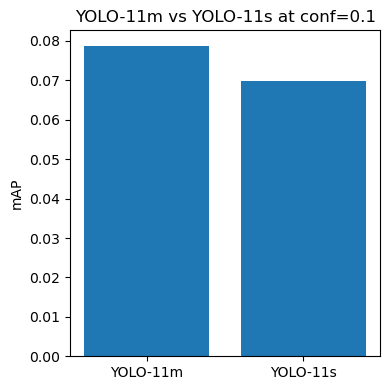

In [57]:
from ultralytics import YOLO

yolo_model_s = YOLO("yolo11s.pt").to(device)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# If needed, reload previous results
df_zero_shot = pd.read_csv("task2_zero_shot_taco_results.csv")

# pick best confidence for the original YOLO (top-k, based on mAP)
df_yolo_topk = df_zero_shot[
    (df_zero_shot["model"] == "YOLO") &
    (df_zero_shot["selection"] == "top-k")
]

best_row = df_yolo_topk.loc[df_yolo_topk["map"].idxmax()]
best_conf = float(best_row["conf"])

print("Best confidence for original YOLO (top-k):", best_conf)

# evaluate YOLO-11s at the same confidence
yolo_s_map, _, _, iou_yolo_s_map, _, _ = evaluate_models(
    yolo_model_s,
    detr_model,
    rt_detr_model,
    test_loader,
    yolo_conf=best_conf,
    detr_conf=best_conf,
    rt_detr_conf=best_conf,
)

yolo_s_metrics = extract_scalar_metrics(yolo_s_map)

# build direct comparison table YOLO-11m vs YOLO-11s (top-k, best_conf)
metric_cols = [c for c in df_zero_shot.columns if c not in ["model", "selection", "conf"]]

row_m = {
    "model": "YOLO-11m",
    "selection": "top-k",
    "conf": best_conf,
}
row_m.update({k: best_row[k] for k in metric_cols if k in best_row})

row_s = {
    "model": "YOLO-11s",
    "selection": "top-k",
    "conf": best_conf,
}
row_s.update(yolo_s_metrics)

df_yolo_size = pd.DataFrame([row_m, row_s])

print("YOLO size comparison at best confidence (top-k):")
display(df_yolo_size.round(3))

# simple bar plot for mAP comparison
plt.figure(figsize=(4, 4))
plt.bar(df_yolo_size["model"], df_yolo_size["map"])
plt.ylabel("mAP")
plt.title(f"YOLO-11m vs YOLO-11s at conf={best_conf}")
plt.tight_layout()
plt.show()



At the same confidence threshold (0.1), YOLO-11m performs slightly better than YOLO-11s across all main metrics.
The medium model achieves higher mAP (0.079 vs 0.070), mAP@50, and mAP@75, and also shows consistently higher mAP_medium and mAP_large.
Recall metrics (MAR@1, MAR@10, MAR@100) follow the same trend: YOLO-11m retrieves more correct objects on average.

Both models score 0 on small objects, indicating that neither variant is able to detect very small items in this zero-shot setting.

Overall, YOLO-11m is more reliable at low confidence, providing better precision and recall, while YOLO-11s is slightly weaker but still follows a similar behavior.

YOLO-11m performs better than YOLO-11s simply because it is a **bigger and stronger model**.
It has more layers and learns richer visual features, so it can recognize objects more reliably, especially in a complex dataset like TACO where items vary a lot in shape, texture, and lighting.
YOLO-11s is faster and lighter, but this comes at the cost of lower accuracy.



## Task 2.3. finetuning detr

In [12]:
from transformers import AutoImageProcessor
IMG_SIZE = 480
checkpoint = "PekingU/rtdetr_v2_r50vd"


label2id = {'Plastic bag & wrapper': 0,
  'Cigarette': 1,
  'Bottle': 2,
  'Bottle cap': 3,
  'Can': 4,
  'Carton': 5}

id2label = {v: k for k, v in label2id.items()}
label2id, id2label
categories = list(id2label.values())

image_processor = AutoImageProcessor.from_pretrained(
    checkpoint,
    do_resize=True,
    size={"height": IMG_SIZE, "width": IMG_SIZE},
    use_fast=True,
)


In [13]:
print("Evaluating models on the test dataset...")

yolo_map, detr_map, rt_detr_map, iou_yolo_map, iou_detr_map, iou_rt_detr_map = evaluate_models(yolo_model, detr_model, rt_detr_model, test_loader)
print(f"YOLO mAP: {yolo_map}")
print(f"DETR mAP: {detr_map}")
print(f"RT-DETR mAP: {rt_detr_map}")

print(f"YOLO IoU-based mAP: {iou_yolo_map}")
print(f"DETR IoU-based mAP: {iou_detr_map}")
print(f"RT-DETR IoU-based mAP: {iou_rt_detr_map}")

Evaluating models on the test dataset...
YOLO mAP: {'map': tensor(0.0562), 'map_50': tensor(0.0641), 'map_75': tensor(0.0567), 'map_small': tensor(0.), 'map_medium': tensor(0.0520), 'map_large': tensor(0.1120), 'mar_1': tensor(0.0881), 'mar_10': tensor(0.1035), 'mar_100': tensor(0.1035), 'mar_small': tensor(0.), 'mar_medium': tensor(0.0828), 'mar_large': tensor(0.2250), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(0, dtype=torch.int32)}
DETR mAP: {'map': tensor(0.0524), 'map_50': tensor(0.0753), 'map_75': tensor(0.0541), 'map_small': tensor(0.0003), 'map_medium': tensor(0.0836), 'map_large': tensor(0.0953), 'mar_1': tensor(0.1033), 'mar_10': tensor(0.1291), 'mar_100': tensor(0.1291), 'mar_small': tensor(0.0014), 'mar_medium': tensor(0.1388), 'mar_large': tensor(0.2473), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(0, dtype=torch.int32)}
RT-DETR mAP: {'map': tensor(0.0625), 'map_50': tensor(0.0758), 'map_75': tens

In [14]:
import albumentations as A

train_augmentation_and_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True,
                            min_area=25,        # Discard boxes smaller than 5x5 pixels
                            min_visibility=0.1, # Discard boxes if <10% remains after cropping
                            filter_invalid_bboxes=True,
                            min_width=1,
                            min_height=1
                            ),
)

validation_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(format="coco", label_fields=["category"],
                             clip=True,
                             min_visibility=0.1, # Discard boxes if <10% remains after cropping
                            filter_invalid_bboxes=True,
                            min_width=1,
                            min_height=1
                            ),
)

In [15]:
#load datasets with provided custom dataset class

from taco_dataset import TACODETRDetectionDataset


train_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_train.json',processor=image_processor, transform=train_augmentation_and_transform)
test_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_test.json',processor=image_processor, transform= validation_transform)
val_dataset = TACODETRDetectionDataset(img_folder=root, ann_file=root+'/annotations_val.json',processor=image_processor, transform=validation_transform)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (4, 4)
Categories shape: (4,)


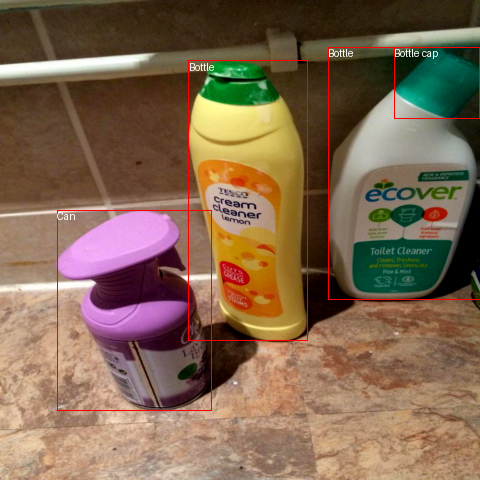

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (1, 4)
Categories shape: (1,)


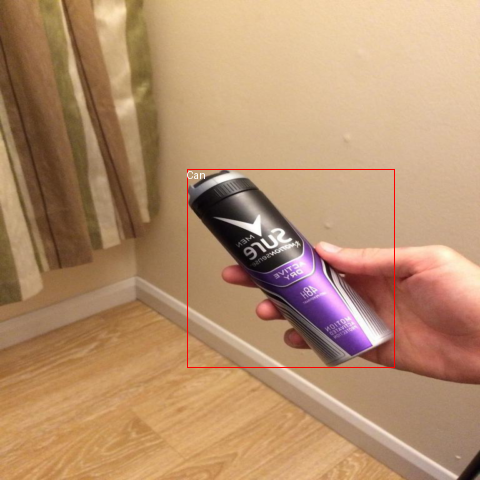

Image tensor shape: torch.Size([3, 480, 480])
Boxes shape: (1, 4)
Categories shape: (1,)


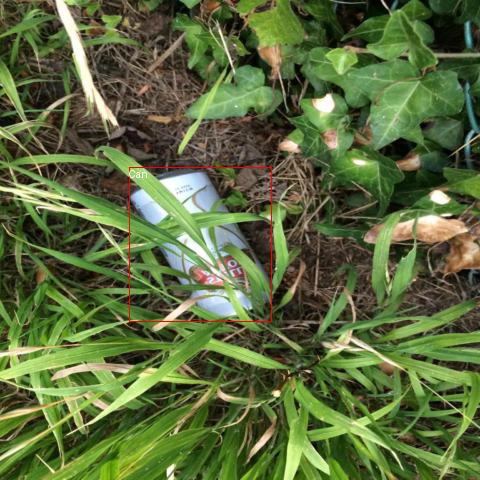

In [16]:
from PIL import Image, ImageDraw
for i in [15, 16, 17]:
    sample = train_dataset[i]

    # De-normalize image
    image = sample["pixel_values"]
    print("Image tensor shape:", image.shape)
    image = image.numpy().transpose(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min()) * 255.
    image = Image.fromarray(image.astype(np.uint8))

    # Convert boxes from [center_x, center_y, width, height] to [x, y, width, height] for visualization
    boxes = sample["labels"]["boxes"].numpy()
    print("Boxes shape:", boxes.shape)
    boxes[:, :2] = boxes[:, :2] - boxes[:, 2:] / 2
    w, h = image.size
    boxes = boxes * np.array([w, h, w, h])[None]

    categories = sample["labels"]["class_labels"].numpy()
    print("Categories shape:", categories.shape)

    # Draw boxes and labels on image
    draw = ImageDraw.Draw(image)
    for box, category in zip(boxes, categories):
        x, y, w, h = box
        draw.rectangle([x, y, x + w, y + h], outline="red", width=1)
        draw.text((x, y), id2label[category], fill="white")

    display(image)

In [17]:
from dataclasses import dataclass
from transformers.image_transforms import center_to_corners_format

@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor

class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label
    def collect_image_sizes(self,targets):
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x['size'] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes
    def collect_targets(self, targets, image_sizes):
        post_processed_targets=[]
        for target_batch, image_size_batch in zip(targets, image_sizes):
            batch_targets = []
            for target, size in zip(target_batch, image_size_batch):
                height, width = size
                boxes = torch.tensor(target['boxes'])
                boxes = center_to_corners_format(boxes)
                boxes = boxes * torch.tensor([width, height, width, height], dtype=torch.float32)

                labels = torch.tensor(target['class_labels'])
                post_processed_targets.append({'boxes': boxes, 'labels': labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")

        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = self.id2label[class_id.item()] if self.id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}
        return metrics


eval_compute_metrics_fn = MAPEvaluator(image_processor=image_processor, threshold=0.1, id2label=None)

In [18]:
from transformers import AutoModelForObjectDetection

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label= id2label,
    label2id= label2id,
    num_labels=len(id2label),
    ignore_mismatched_sizes=True,
)

Some weights of RTDetrV2ForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_v2_r50vd and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([6]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([6, 256]) in the model instantiated
- model.decod

In [19]:
from taco_dataset import taco_detr_collate_fn
collate_fn = taco_detr_collate_fn

In [20]:
#if you don't have / want to use wandb account, set it to offline mode
os.environ['WANDB_MODE']= 'offline'

from transformers import TrainingArguments, Trainer
training_args = TrainingArguments(
    output_dir=f"{checkpoint}-finetuned-taco",
    num_train_epochs=2,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=8,
    dataloader_num_workers=2,
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    logging_strategy="steps",
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    report_to="wandb",
    fp16 = True #for colab T4 instance
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=image_processor,
    data_collator = collate_fn,
    compute_metrics = eval_compute_metrics_fn,
)


⚙️  Running in WANDB offline mode


In [ ]:
#wandb setup, comment this if you don't want to use wandb
import wandb
run = wandb.init(project="VisComp2025-Assignment2", name="RT-DETR-finetuned-on-TACO")


wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:

In [21]:
trainer.train()
run.finish()

Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map 0,Mar 100 0,Map 1,Mar 100 1,Map 2,Mar 100 2,Map 3,Mar 100 3,Map 4,Mar 100 4,Map 5,Mar 100 5
1,117.129900,81.399139,0.007000,0.008600,0.007900,0.000700,0.004500,0.027700,0.036200,0.075500,0.116300,0.061000,0.104700,0.296200,0.000700,0.150400,0.000000,0.004800,0.000700,0.174300,0.000000,0.000000,0.040300,0.304300,0.000200,0.063900
2,42.987100,29.907000,0.088400,0.112800,0.094200,0.035000,0.125500,0.171700,0.218000,0.343400,0.364900,0.174400,0.490400,0.561700,0.200600,0.408000,0.000200,0.062900,0.095200,0.510000,0.027500,0.251400,0.146700,0.540400,0.060300,0.416700


There were missing keys in the checkpoint model loaded: ['class_embed.0.weight', 'class_embed.0.bias', 'class_embed.1.weight', 'class_embed.1.bias', 'class_embed.2.weight', 'class_embed.2.bias', 'class_embed.3.weight', 'class_embed.3.bias', 'class_embed.4.weight', 'class_embed.4.bias', 'class_embed.5.weight', 'class_embed.5.bias', 'bbox_embed.0.layers.0.weight', 'bbox_embed.0.layers.0.bias', 'bbox_embed.0.layers.1.weight', 'bbox_embed.0.layers.1.bias', 'bbox_embed.0.layers.2.weight', 'bbox_embed.0.layers.2.bias', 'bbox_embed.1.layers.0.weight', 'bbox_embed.1.layers.0.bias', 'bbox_embed.1.layers.1.weight', 'bbox_embed.1.layers.1.bias', 'bbox_embed.1.layers.2.weight', 'bbox_embed.1.layers.2.bias', 'bbox_embed.2.layers.0.weight', 'bbox_embed.2.layers.0.bias', 'bbox_embed.2.layers.1.weight', 'bbox_embed.2.layers.1.bias', 'bbox_embed.2.layers.2.weight', 'bbox_embed.2.layers.2.bias', 'bbox_embed.3.layers.0.weight', 'bbox_embed.3.layers.0.bias', 'bbox_embed.3.layers.1.weight', 'bbox_embed.3.l

NameError: name 'run' is not defined

In [29]:
# ====== Task 2.3 — Final evaluation on TACO TEST split ======
print("Evaluating the fine-tuned RT-DETR model on the TACO TEST set...")

test_metrics = trainer.evaluate(test_dataset)

# Round for readability
test_metrics_rounded = {k: round(float(v), 4) for k, v in test_metrics.items()}

print("Final Test Metrics:")
for k, v in test_metrics_rounded.items():
    print(f"{k}: {v}")

# Convert to a DataFrame (useful for report)
import pandas as pd
df_test_results = pd.DataFrame([test_metrics_rounded])

# Save to CSV
df_test_results.to_csv("task2_finetuned_rtdetr_test_results.csv", index=False)

print("\nSaved test results to task2_finetuned_rtdetr_test_results.csv")


Evaluating the fine-tuned RT-DETR model on the TACO TEST set...


Final Test Metrics:
eval_loss: 30.5467
eval_map: 0.1063
eval_map_50: 0.1289
eval_map_75: 0.1125
eval_map_small: 0.0397
eval_map_medium: 0.1103
eval_map_large: 0.2739
eval_mar_1: 0.2313
eval_mar_10: 0.3771
eval_mar_100: 0.387
eval_mar_small: 0.1742
eval_mar_medium: 0.4969
eval_mar_large: 0.7018
eval_map_0: 0.1543
eval_mar_100_0: 0.4007
eval_map_1: 0.0002
eval_mar_100_1: 0.027
eval_map_2: 0.0858
eval_mar_100_2: 0.5137
eval_map_3: 0.029
eval_mar_100_3: 0.3355
eval_map_4: 0.3191
eval_mar_100_4: 0.5837
eval_map_5: 0.0493
eval_mar_100_5: 0.4613
eval_runtime: 47.304
eval_samples_per_second: 3.763
eval_steps_per_second: 0.486
epoch: 2.0

Saved test results to task2_finetuned_rtdetr_test_results.csv


In [ ]:



run = wandb.init(project="VisComp2025-Assignment2", name="RT-DETR-finetuned-on-TACO",id=run.id, resume="allow")

# Folder where Trainer stored the best model
best_dir = "rt_detr_taco_best"

# 1. Save best model weights + processor to a folder
trainer.model.save_pretrained(best_dir)
image_processor.save_pretrained(best_dir)

# 2. Create artifact
artifact = wandb.Artifact(
    name="rtdetr_taco_best",
    type="model",
    description="Best RT-DETR model selected by eval_map",
)

# 3. Add the entire folder to the artifact
artifact.add_dir(best_dir)

# 4. Log artifact to W&B
run.log_artifact(artifact)

# 5. Optional: wait until upload finishes
artifact.wait()

run.finish()


NameError: name 'wandb' is not defined

['train/epoch', 'eval/map_4', 'eval/map_50', 'eval/mar_100_5', 'eval/map_medium', 'eval/map_1', 'eval/samples_per_second', 'eval/loss', 'eval/map_0', 'eval/map_3', 'train/grad_norm', '_timestamp', 'eval/mar_100_0', 'eval/map_75', 'train/loss', 'eval/map_small', 'eval/steps_per_second', 'eval/mar_100_1', 'eval/mar_large', 'eval/map_5', 'train/learning_rate', '_step', 'eval/mar_small', 'eval/mar_10', 'eval/mar_100', 'eval/mar_100_2', 'eval/mar_medium', 'eval/map_large', 'train/global_step', '_runtime', 'eval/mar_1', 'eval/mar_100_3', 'eval/map', 'eval/map_2', 'eval/runtime', 'eval/mar_100_4']


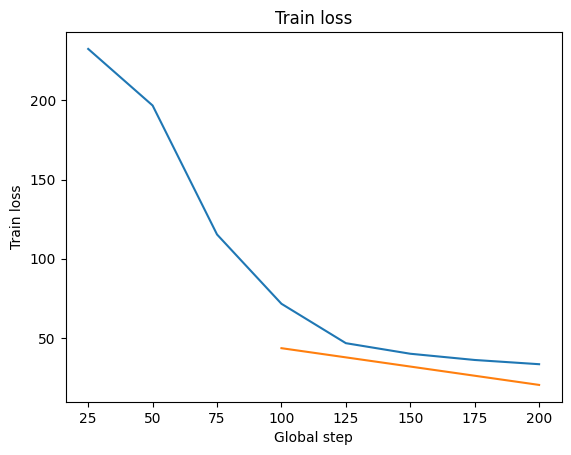

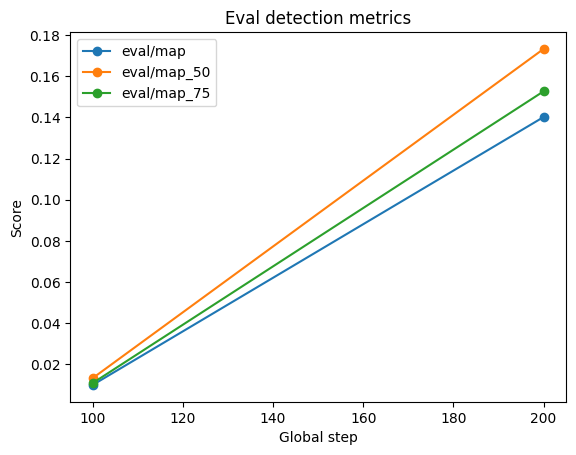

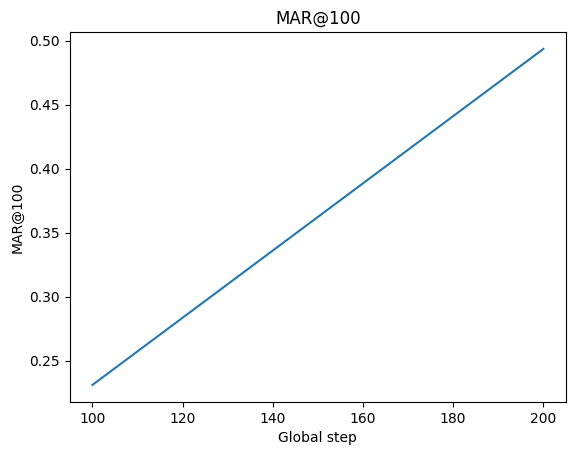

In [27]:
api = wandb.Api()


results = api.run(f"VisComp2025-Assignment2/runs/{run.id}").history(samples=None)
print(results.columns.tolist())

import matplotlib.pyplot as plt

step_col = "train/global_step"  # or "_step", both exist
train_col = "train/loss"
eval_col = "eval/loss"

train_hist = results[[step_col, train_col]].dropna()
eval_hist = results[[step_col, eval_col]].dropna()

plt.figure()
plt.plot(train_hist[step_col], train_hist[train_col])
plt.plot(eval_hist[step_col], eval_hist[eval_col])
plt.xlabel("Global step")
plt.ylabel("Train loss")
plt.title("Train loss")
plt.show()

metrics = ["eval/map", "eval/map_50", "eval/map_75"]

plt.figure()
for m in metrics:
    sub = results[[step_col, m]].dropna()
    plt.plot(sub[step_col], sub[m], marker="o", label=m)

plt.xlabel("Global step")
plt.ylabel("Score")
plt.title("Eval detection metrics")
plt.legend()
plt.show()

train_hist = results[[step_col,"eval/mar_100"]].dropna()
plt.figure()
plt.plot(train_hist[step_col], train_hist["eval/mar_100"])
plt.xlabel("Global step")
plt.ylabel("MAR@100")
plt.title("MAR@100")
plt.show()


In [24]:
#obtain epoch that generated best model

metric_col = "eval/map"
step_col = "_step"
idx = results[metric_col].idxmax()

row = results.loc[idx]

print("Best eval_map:", row[metric_col])
print("At epoch:", row.get("train/epoch"))
print("At step:", row.get("_step") or row.get("train/global_step"))
row

NameError: name 'results' is not defined

inference on a single image

Detected Can with confidence 0.318 at location [129.27, 231.45, 283.98, 318.42]


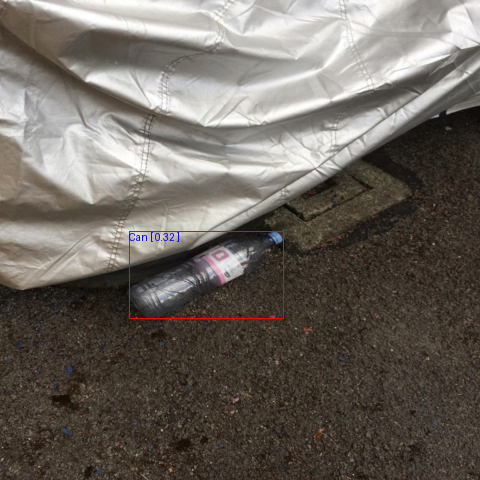

In [30]:

image_index = 2

# The model always expects a batch, so we need to collate our single sample into a batch
inputs = taco_detr_collate_fn([train_dataset[image_index]])
inputs = {k: ( v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

inputs.pop("labels")  # Remove labels for inference
with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([(IMG_SIZE, IMG_SIZE)])

result = image_processor.post_process_object_detection(outputs,
                                                       threshold=0.3, # Confidence threshold
                                                       target_sizes=target_sizes)[0]

for score, label, box in zip(result["scores"], result["labels"], result["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{round(score.item(), 3)} at location {box}"
    )

image = inputs["pixel_values"][0].detach().cpu()
image_with_boxes = image.numpy().transpose(1, 2, 0)
image_with_boxes = (image_with_boxes - image_with_boxes.min()) / (image_with_boxes.max() - image_with_boxes.min()) * 255.
image_with_boxes = Image.fromarray(image_with_boxes.astype(np.uint8))

draw = ImageDraw.Draw(image_with_boxes)

for score, label, box in zip(result["scores"], result["labels"], result["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    x, y, x2, y2 = tuple(box)
    draw.rectangle((x, y, x2, y2), outline="red", width=1)
    text_label = model.config.id2label[label.item()]
    draw.text((x, y), f"{text_label} [ {score.item():.2f} ]", fill="blue")

image_with_boxes